# AI_powered_car_dent_and_damage_detection

## Dataset

### Classes : 

class_labels = [
    "Front-windscreen-damage",
    "Headlight-damage",
    "Rear-windscreen-damage",
    "Runningboard-damage",
    "Sidemirror-damage",
    "Taillight-damage",
    "Bonnet-dent",
    "Boot-dent",
    "Doorouter-dent",
    "Fender-dent",
    "Front-bumper-dent",
    "Quaterpanel-dent",
    "Rear-bumper-dent",
    "Roof-dent",
    "Wheel-damaged"
]




In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [14]:
import os

dataset_path = "/kaggle/input"
print("Available datasets:", os.listdir(dataset_path))


Available datasets: ['car-damage-detection-dataset']


In [15]:
DATA_DIR = '/kaggle/input/car-damage-detection-dataset'
WORK_DIR = '/kaggle/working/'

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 14
names: ['Front-windscreen-damage', 'Headlight-damage', 'Rear-windscreen-Damage', 'Runningboard-Damage', 'Sidemirror-Damage', 'Taillight-Damage', 'bonnet-dent', 'boot-dent', 'doorouter-dent', 'fender-dent', 'front-bumper-dent', 'quaterpanel-dent', 'rear-bumper-dent', 'roof-dent']


In [16]:
# # -----------------------------------------------------------------------
# # Run this code for only onetime to create YAML file for our dataset. --
# # -----------------------------------------------------------------------

import os
import yaml

num_classes = 14
classes = ['Front-windscreen-damage', 'Headlight-damage', 'Rear-windscreen-Damage', 'Runningboard-Damage', 'Sidemirror-Damage', 'Taillight-Damage', 'bonnet-dent', 'boot-dent', 'doorouter-dent', 'fender-dent', 'front-bumper-dent', 'quaterpanel-dent', 'rear-bumper-dent', 'roof-dent']
dict_file = {'train': os.path.join(DATA_DIR, 'train'),
             'val': os.path.join(DATA_DIR, 'valid'),
             'test': os.path.join(DATA_DIR, 'test'),
             'nc': num_classes,
             'names': classes
            }

with open(os.path.join(WORK_DIR, 'data.yaml'), 'w+') as file:
    yaml.dump(dict_file, file)

In [17]:
import os
import glob

FOLDER_NAME = "labels"

matching_folders = glob.glob(f"{DATA_DIR}/**/{FOLDER_NAME}", recursive=True)

print("Matching Folders:", matching_folders)

NUM_CLASSES = 14
classes_distribution = [0] * NUM_CLASSES

for i in matching_folders:
    label_files = glob.glob(os.path.join(i, "*.txt"))
    for file_path in label_files:
        with open(file_path, "r") as f:
            lines = f.readlines()
            for line in lines:
                class_id = line.strip().split()[0]
                if class_id.isdigit():
                    class_id = int(class_id)
                    if 0 <= class_id < NUM_CLASSES:
                        classes_distribution[class_id] += 1

print("Class Distribution:", classes_distribution)


Matching Folders: ['/kaggle/input/car-damage-detection-dataset/valid/labels', '/kaggle/input/car-damage-detection-dataset/test/labels', '/kaggle/input/car-damage-detection-dataset/train/labels']
Class Distribution: [293, 664, 458, 347, 283, 449, 1256, 167, 1599, 1041, 1913, 841, 1060, 398]


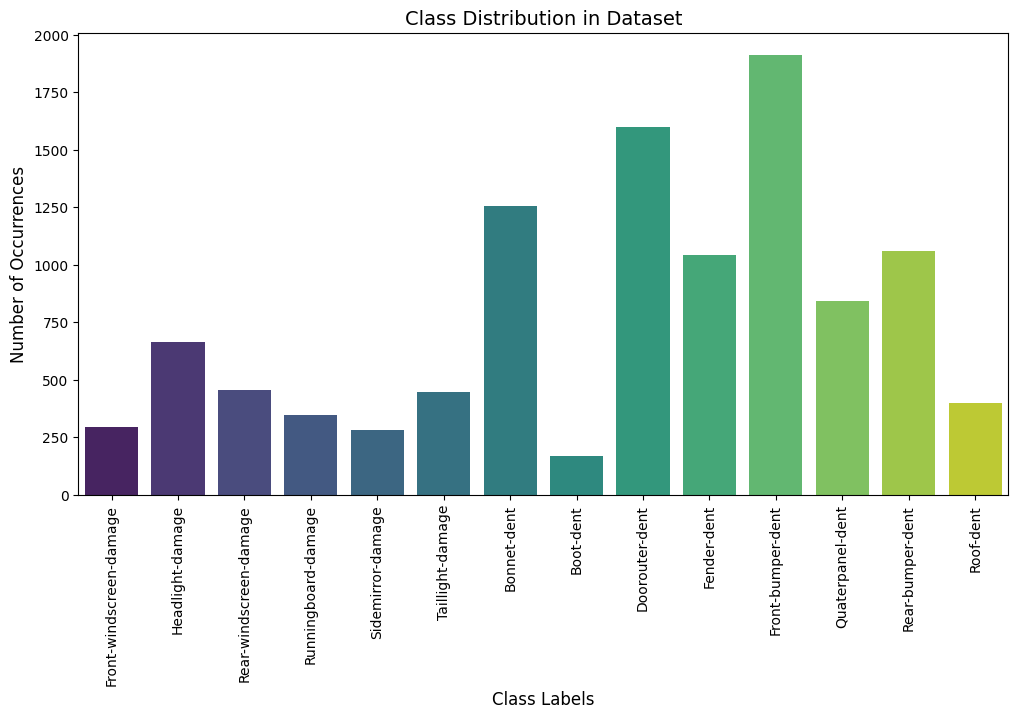

In [18]:
class_labels = [
    "Front-windscreen-damage",
    "Headlight-damage",
    "Rear-windscreen-damage",
    "Runningboard-damage",
    "Sidemirror-damage",
    "Taillight-damage",
    "Bonnet-dent",
    "Boot-dent",
    "Doorouter-dent",
    "Fender-dent",
    "Front-bumper-dent",
    "Quaterpanel-dent",
    "Rear-bumper-dent",
    "Roof-dent"
]

# Create a DataFrame
df = pd.DataFrame({"Class": class_labels, "Count": classes_distribution})

# Plot using the DataFrame
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Class", y="Count", palette="viridis")

plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Occurrences", fontsize=12)
plt.title("Class Distribution in Dataset", fontsize=14)
plt.xticks(rotation=90)

plt.show()


# **Sample Image with detected damages**

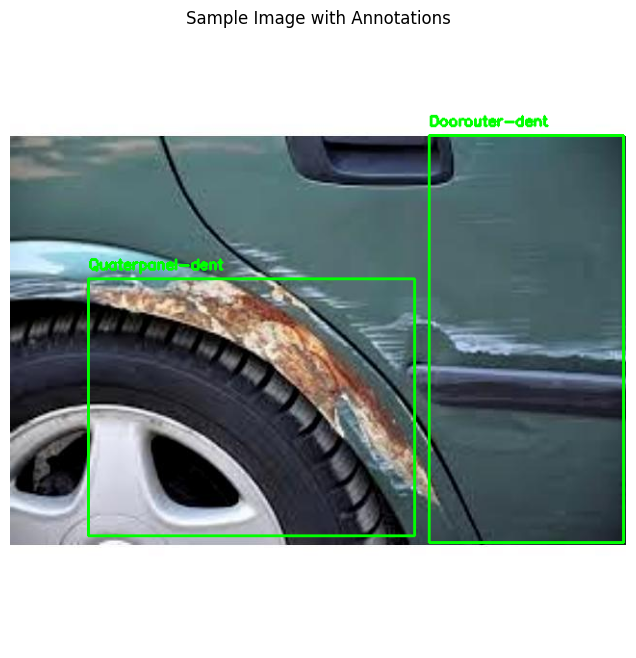

In [19]:
import cv2

sample_img_path = "/kaggle/input/car-damage-detection-dataset/test/images/0053_JPEG_jpg.rf.8ea870ef62af4f5ee8b33d4c363bddcb.jpg"

img = cv2.imread(sample_img_path)
h, w, _ = img.shape

label_file = "/kaggle/input/car-damage-detection-dataset/test/labels/0053_JPEG_jpg.rf.8ea870ef62af4f5ee8b33d4c363bddcb.txt"

if os.path.exists(label_file):
    with open(label_file, "r") as f:
        lines = f.readlines()
        for line in lines:
            class_id, x, y, bbox_w, bbox_h = map(float, line.strip().split())
            x1 = int((x - bbox_w / 2) * w)
            y1 = int((y - bbox_h / 2) * h)
            x2 = int((x + bbox_w / 2) * w)
            y2 = int((y + bbox_h / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, class_labels[int(class_id)], (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Sample Image with Annotations")
plt.axis("off")
plt.show()


# **Yolo model training**

In [20]:
!pip install ultralytics

In [21]:
from ultralytics import YOLO
model = YOLO('yolov8s.pt')

In [22]:
model.train(data=os.path.join(WORK_DIR,'data.yaml'),task='detect',imgsz=640,epochs=100,batch=-1,mode='train',name='yolov8s_v1_train')

Ultralytics 8.3.97 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/kaggle/working/data.yaml, epochs=100, time=None, patience=100, batch=-1, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=yolov8s_v1_train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True

100%|██████████| 755k/755k [00:00<00:00, 18.0MB/s]


Overriding model.yaml nc=80 with nc=14

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytic

100%|██████████| 5.35M/5.35M [00:00<00:00, 76.4MB/s]


AMP: checks passed ✅


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:10<00:00,  1.05s/it]


                   all       1043       1610      0.891      0.762      0.834      0.675
Front-windscreen-damage         49         50      0.953       0.72      0.837      0.703
      Headlight-damage         89         90       0.84      0.767      0.805      0.586
Rear-windscreen-Damage         77         77       0.98      0.831      0.917      0.789
   Runningboard-Damage         43         50      0.828       0.77      0.816      0.686
     Sidemirror-Damage         42         42          1      0.923      0.959      0.873
      Taillight-Damage         70         72      0.845      0.833      0.852      0.732
           bonnet-dent        189        194      0.953      0.763      0.867      0.661
             boot-dent         25         26      0.678      0.462      0.464      0.234
        doorouter-dent        192        259      0.922       0.78      0.875       0.72
           fender-dent        136        137      0.848      0.694      0.801      0.611
     front-bumper-de

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 4.8ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/detect/yolov8s_v1_train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79af4c32a200>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

In [23]:
model.val()

Ultralytics 8.3.97 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,131,002 parameters, 0 gradients, 28.5 GFLOPs


val: Scanning /kaggle/input/car-damage-detection-dataset/valid/labels... 1043 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1043/1043 [00:01<00:00, 829.09it/s]

val: WARNING ⚠️ Cache directory /kaggle/input/car-damage-detection-dataset/valid is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 20/20 [00:15<00:00,  1.31it/s]


                   all       1043       1610      0.891      0.762      0.834      0.675
Front-windscreen-damage         49         50      0.953       0.72      0.838      0.704
      Headlight-damage         89         90      0.838      0.767      0.805      0.587
Rear-windscreen-Damage         77         77       0.98      0.831      0.917      0.789
   Runningboard-Damage         43         50      0.828      0.769      0.816      0.682
     Sidemirror-Damage         42         42          1      0.923      0.959      0.872
      Taillight-Damage         70         72      0.845      0.833      0.852      0.732
           bonnet-dent        189        194      0.952      0.763      0.867       0.66
             boot-dent         25         26       0.68      0.462      0.465      0.234
        doorouter-dent        192        259      0.921       0.78      0.875       0.72
           fender-dent        136        137      0.848      0.694      0.801      0.611
     front-bumper-de

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 1.0ms preprocess, 9.3ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to runs/detect/yolov8s_v1_train22


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79af46b07910>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

In [24]:
test_results = model.predict(source=os.path.join(DATA_DIR, 'test', 'images'), save=True)


image 1/698 /kaggle/input/car-damage-detection-dataset/test/images/0020_JPEG_jpg.rf.6e9dae2970b66c9cf28e48a0de6c5b4f.jpg: 640x640 1 Rear-windscreen-Damage, 16.3ms
image 2/698 /kaggle/input/car-damage-detection-dataset/test/images/0030_JPEG_jpg.rf.4deb9ea5a16e3e86dcab01f11184ad50.jpg: 640x640 1 doorouter-dent, 16.2ms
image 3/698 /kaggle/input/car-damage-detection-dataset/test/images/0045_JPEG_jpg.rf.6d432df55240a7139330d0217f084e85.jpg: 640x640 1 Rear-windscreen-Damage, 16.2ms
image 4/698 /kaggle/input/car-damage-detection-dataset/test/images/0046_JPEG_jpg.rf.29237559bdd864402f7817bde8d46686.jpg: 640x640 1 Rear-windscreen-Damage, 16.3ms
image 5/698 /kaggle/input/car-damage-detection-dataset/test/images/0049_JPEG_jpg.rf.f75c95975cbd24e07845c3d219dc655c.jpg: 640x640 (no detections), 16.3ms
image 6/698 /kaggle/input/car-damage-detection-dataset/test/images/0053_JPEG_jpg.rf.8ea870ef62af4f5ee8b33d4c363bddcb.jpg: 640x640 1 doorouter-dent, 1 quaterpanel-dent, 16.3ms
image 7/698 /kaggle/input/

In [25]:
test_results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Front-windscreen-damage', 1: 'Headlight-damage', 2: 'Rear-windscreen-Damage', 3: 'Runningboard-Damage', 4: 'Sidemirror-Damage', 5: 'Taillight-Damage', 6: 'bonnet-dent', 7: 'boot-dent', 8: 'doorouter-dent', 9: 'fender-dent', 10: 'front-bumper-dent', 11: 'quaterpanel-dent', 12: 'rear-bumper-dent', 13: 'roof-dent'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 25

In [26]:
model = YOLO("/kaggle/working/runs/detect/yolov8s_v1_train2/weights/best.pt")
video_path = "/kaggle/input/sample-video-1/sample_video_1.mp4"
results = model.predict(source=video_path, save=True, conf=0.5)
print("Processed video saved at:", results[0].save_dir)



WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/420) /kaggle/input/sample-video-1/sample_video_1.mp4: 384x640 1 Front-windscreen-damage, 40.2ms
video 1/1 (frame 2/420) /kaggle/input/sample-video-1/sample_video_1.mp4: 384x640 1 Front-windscreen-damage, 10.7ms
video 1/1 (frame 3/420) /kaggle/input/sample-video-1/sample_video_1.mp4: 384x640 1 Front-windscreen-damage, 10.7ms
video 1/1 (frame 4/420) /kaggle/input/sample-video-1/sample_video_1.mp4: 384x640 (no detections), 10.7ms
video 

In [27]:
model = YOLO("/kaggle/working/runs/detect/yolov8s_v1_train2/weights/best.pt")
video_path = "/kaggle/input/sample-video-1/sample_video_2.mp4"
results = model.predict(source=video_path, save=True, conf=0.5)
print("Processed video saved at:", results[0].save_dir)



WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/413) /kaggle/input/sample-video-1/sample_video_2.mp4: 384x640 2 doorouter-dents, 11.4ms
video 1/1 (frame 2/413) /kaggle/input/sample-video-1/sample_video_2.mp4: 384x640 2 doorouter-dents, 10.7ms
video 1/1 (frame 3/413) /kaggle/input/sample-video-1/sample_video_2.mp4: 384x640 2 doorouter-dents, 10.7ms
video 1/1 (frame 4/413) /kaggle/input/sample-video-1/sample_video_2.mp4: 384x640 2 doorouter-dents, 10.7ms
video 1/1 (frame 5/413) /kag

In [28]:
model.export(format="onnx")

Ultralytics 8.3.97 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/detect/yolov8s_v1_train2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 18, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnxslim', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.8/280.8 MB 302.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 182.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 302.7 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 10.9s, installed 2 packages: ['onnxslim', 'onnxruntime-gpu']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.49...
ONNX: export success ✅ 12.6s, saved as '/kaggle/working

'/kaggle/working/runs/detect/yolov8s_v1_train2/weights/best.onnx'

In [41]:
pip install onnx2tf onnx_graphsurgeon ai_edge_litert sng4onnx tflite_support


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 MB 29.0 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [44]:
model.export(format="tf")

WARNING ⚠️ Invalid export format='tf', updating to format='tfjs'
Ultralytics 8.3.97 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/detect/yolov8s_v1_train2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 18, 8400) (21.5 MB)

TensorFlow SavedModel: starting export with tensorflow 2.17.1...

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.49...
ONNX: export success ✅ 1.5s, saved as '/kaggle/working/runs/detect/yolov8s_v1_train2/weights/best.onnx' (42.7 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.27.1...
TensorFlow SavedModel: export success ✅ 72.8s, saved as '/kaggle/working/runs/detect/yolov8s_v1_train2/weights/best_saved_model' (107.1 MB)

TensorFlow GraphDef: starting export with tensorflow 2.17.1...
TensorFlow GraphDef: export success ✅ 1.9s, saved as '/kaggle/working/runs/detect/yolov8s_v1_train2/weights/best.pb' (42.7 MB)

TensorFlow.js

'/kaggle/working/runs/detect/yolov8s_v1_train2/weights/best_web_model'

In [47]:
!zip -r /kaggle/working/workspace_with_augmentation.zip /kaggle/working/

updating: kaggle/working/ (stored 0%)
updating: kaggle/working/runs/ (stored 0%)
updating: kaggle/working/runs/detect/ (stored 0%)
updating: kaggle/working/runs/detect/yolov8s_v1_train22/ (stored 0%)
updating: kaggle/working/runs/detect/yolov8s_v1_train22/val_batch0_labels.jpg (deflated 5%)
updating: kaggle/working/runs/detect/yolov8s_v1_train22/val_batch2_pred.jpg (deflated 14%)
updating: kaggle/working/runs/detect/yolov8s_v1_train22/P_curve.png (deflated 7%)
updating: kaggle/working/runs/detect/yolov8s_v1_train22/R_curve.png (deflated 7%)
updating: kaggle/working/runs/detect/yolov8s_v1_train22/val_batch0_pred.jpg (deflated 5%)
updating: kaggle/working/runs/detect/yolov8s_v1_train22/F1_curve.png (deflated 6%)
updating: kaggle/working/runs/detect/yolov8s_v1_train22/PR_curve.png (deflated 9%)
updating: kaggle/working/runs/detect/yolov8s_v1_train22/confusion_matrix.png (deflated 18%)
updating: kaggle/working/runs/detect/yolov8s_v1_train22/val_batch2_labels.jpg (deflated 14%)
updating: ka